# GRU-based direct multi-horizon time series forecasting model, full features, window = 90

╒══════════╤═════════════╕
│ metric   │       value │
╞══════════╪═════════════╡
│ MAE      │ 11915.2     │
├──────────┼─────────────┤
│ RMSE     │ 17823.1     │
├──────────┼─────────────┤
│ MAPE (%) │     4.06357 │
╘══════════╧═════════════╛


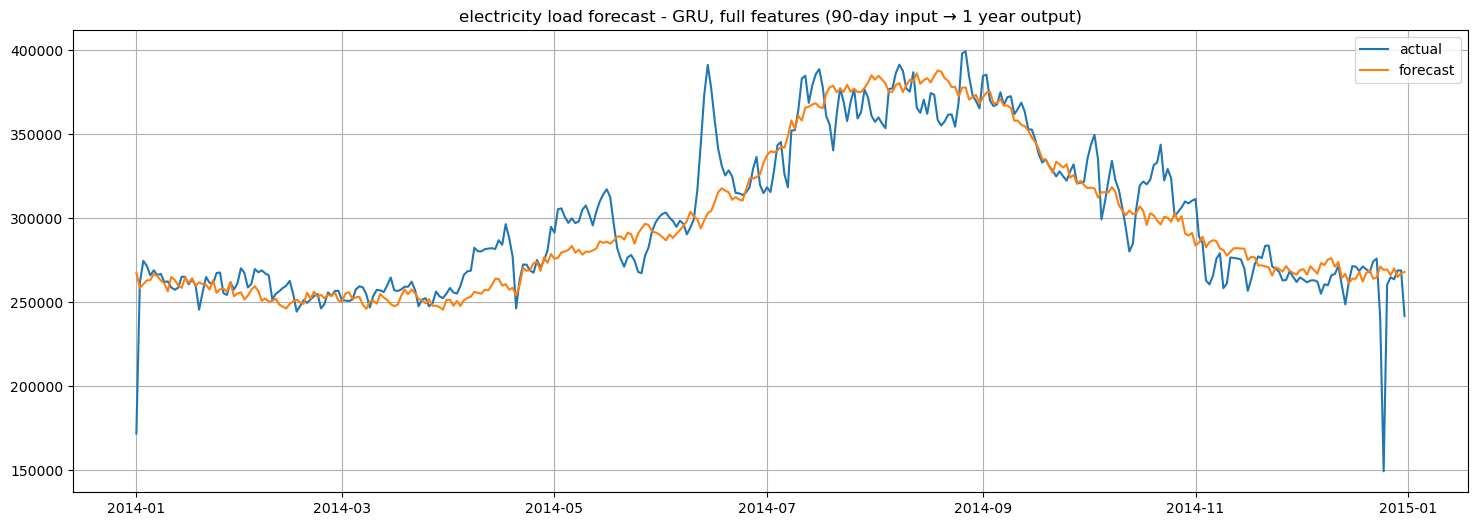

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tabulate import tabulate

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

# load data
path = r"C:\Users\XPS\Desktop\time_series\Electricity-Load-Diagrams\data\processed\data_cleaned\df_clean"
df = pd.read_parquet(path)
df = df.apply(pd.to_numeric, errors="coerce")

# daily aggregation
df_daily = df.resample("D").sum()

# create target variable
df_daily["value"] = df_daily.mean(axis=1)

# create time features
df_daily["dayofyear"] = df_daily.index.dayofyear
df_daily["month"] = df_daily.index.month
df_daily["dayofweek"] = df_daily.index.dayofweek

df_daily["is_weekend"] = (df_daily["dayofweek"] >= 5).astype(int)

df_daily["day_sin"] = np.sin(2 * np.pi * df_daily["dayofyear"] / 365)
df_daily["day_cos"] = np.cos(2 * np.pi * df_daily["dayofyear"] / 365)

df_daily["month_sin"] = np.sin(2 * np.pi * df_daily["month"] / 12)
df_daily["month_cos"] = np.cos(2 * np.pi * df_daily["month"] / 12)

# ensure holiday flag exists
df_daily["holiday_flag"] = 0

# select features
features = [
    "value",
    "day_sin", "day_cos",
    "month_sin", "month_cos",
    "is_weekend",
    "holiday_flag",
]

data = df_daily[features].copy()

# split train and test by year
train_df = data.loc[data.index < "2014-01-01"]
test_df = data.loc[(data.index >= "2014-01-01") & (data.index < "2015-01-01")]

# check target existence
assert "value" in train_df.columns
assert "value" in test_df.columns

# scale data
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

# build sequences
window = 90
horizon = len(test_df)

def create_seq(data):
    X, y = [], []
    for i in range(len(data) - window - horizon):
        X.append(data[i:i + window])
        y.append(data[i + window:i + window + horizon, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_seq(train_scaled)

# build model
model = Sequential([
    Input(shape=(window, train_scaled.shape[1])),

    GRU(128, return_sequences=True),
    Dropout(0.2),

    GRU(64),
    Dropout(0.2),

    Dense(128, activation="relu"),
    Dense(horizon)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="huber"
)

model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    verbose=0
)

# forecast
last_window = train_scaled[-window:]

future_scaled = model.predict(
    last_window.reshape(1, window, train_scaled.shape[1]),
    verbose=0
)[0]

# inverse scaling safely
dummy = np.zeros((horizon, train_scaled.shape[1]))
dummy[:, 0] = future_scaled

future = scaler.inverse_transform(dummy)[:, 0]

# ground truth
true = test_df["value"].values

min_len = min(len(true), len(future))
true = true[:min_len]
future = future[:min_len]

# metrics
mae = mean_absolute_error(true, future)
rmse = np.sqrt(mean_squared_error(true, future))
mape = np.mean(np.abs((true - future) / (true + 1e-6))) * 100

print(tabulate([
    ["MAE", mae],
    ["RMSE", rmse],
    ["MAPE (%)", mape]
], headers=["metric", "value"], tablefmt="fancy_grid"))

# plot result
plt.figure(figsize=(18, 6))
plt.plot(test_df.index[:min_len], true, label="actual")
plt.plot(test_df.index[:min_len], future, label="forecast")
plt.legend()
plt.grid()
plt.title("electricity load forecast - GRU, full features (90-day input → 1 year output)")
plt.show()